## Detection of brain tumour using CNN

In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision import models
from sklearn.model_selection import train_test_split
from PIL import Image
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Define the model class

In [11]:
class CustomResNet50(nn.Module):
    def __init__(self):
        super(CustomResNet50, self).__init__()
        self.backbone = models.resnet50(pretrained = True)
        self.backbone.fc = nn.Identity()
        self.rotation_head = nn.Linear(2048, 4)

        self.rotation_head = nn.Sequential(
            nn.Linear(2048, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
        
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        rotate_pred = self.rotation_head(features)
        return rotate_pred

In [ ]:
# chagne the fc layer out_features from 4 to 1

# load the pretrained model
binary_model = CustomResNet50().to(device)

binary_model.rotation_head = nn.Sequential(
    nn.Linear(2048, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.5),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.SiLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 1)
)

binary_model.load_state_dict(torch.load("binary_model_4.pth"))
binary_model.to(device)

for param in binary_model.parameters():
    param.require_grad = True

for param in binary_model.rotation_head.parameters():
    param.require_grad = True

print(binary_model)

CustomResNet50(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
  

## Define Path for `binary-dataset`

In [5]:
binary_root_path = Path("binary-dataset")
binary_train_dir = binary_root_path / "train"
binary_test_dir =  binary_root_path / "test"

binary_root_path, binary_train_dir, binary_test_dir

(PosixPath('binary-dataset'),
 PosixPath('binary-dataset/train'),
 PosixPath('binary-dataset/test'))

In [ ]:
binary_train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),   # flips
    transforms.RandomRotation(20),            # rotates
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3), # color chaos
    transforms.RandAugment(num_ops=3, magnitude=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

binary_test_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

binary_train_transform, binary_test_transform

(Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
     ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
     RandAugment(num_ops=3, magnitude=8, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ))

## Create the dataset

In [7]:
binary_train_dataset = datasets.ImageFolder(root = binary_train_dir, transform = binary_train_transform)
binary_test_dataset = datasets.ImageFolder(root =  binary_test_dir, transform = binary_test_transform)

# print(binary_train_dataset.class_to_idx)
binary_train_dataset, binary_test_dataset

(Dataset ImageFolder
     Number of datapoints: 21376
     Root location: binary-dataset/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
                ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=None)
                RandAugment(num_ops=3, magnitude=8, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 5713
     Root location: binary-dataset/test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
         

## Know the dataset imbalance

In [8]:
train_labels = [label for img, label in binary_train_dataset.samples]
test_labels = [label for img, label in binary_test_dataset.samples]

train_yes_count = 0
test_yes_count = 0

for label in train_labels:
    if label == 1:
        train_yes_count += 1

for label in test_labels:
    if label == 1:
        test_yes_count += 1

train_yes_to_no_ratio = train_yes_count / (len(train_labels) - train_yes_count)
test_yes_to_no_ratio = test_yes_count / (len(test_labels) - test_yes_count)

pos_weight_train = (len(train_labels) - train_yes_count) / train_yes_count
pos_weight_test = (len(test_labels) - test_yes_count) / test_yes_count

print(f"Tumourous imgs in train dataset: {train_yes_count}")
print(f"Non-tumourous imgs in train dataset: {len(train_labels) - train_yes_count}")
print(f"Tumourous imgs in test datastet: {test_yes_count}")
print(f"Non-tumous imgs in test dataset: {len(test_labels) - test_yes_count}")tumour_classifier = CustomResnet50().to(device)
tumour_classifier.rotation_head[8] = nn.Linear(in_features = 128, out_features = 4)

tumour_classifier.load_state_dict(torch.load("binary_model_4.pth"), strict = False)


Tumourous imgs in train dataset: 12605
Non-tumourous imgs in train dataset: 8771
Tumourous imgs in test datastet: 3333
Non-tumous imgs in test dataset: 2380


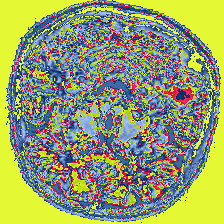

Label: 0


In [9]:
# view the image with label

img_tensor, label = binary_train_dataset[3]

# convert tensor -> PIL
to_pil = transforms.ToPILImage()
img_pil = to_pil(img_tensor)

# show with PIL
img_pil.show()
print(f"Label: {label}")

## Define `DataLoader`, `loss_fn` & `optimizer`

In [10]:
from torch.utils.data import WeightedRandomSampler

class_counts = np.bincount(train_labels)

# assign the class weights
class_weights = 1 / class_counts

sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples = len(sample_weights), replacement = True)

BATCH_SIZE = 64

binary_train_dataloader = DataLoader(dataset = binary_train_dataset, 
                                     batch_size = BATCH_SIZE,
                                    sampler = sampler)

# while using sampler, don't use shuffle = True, it will shuffle the calculation

binary_test_dataloader = DataLoader(dataset = binary_test_dataset,
                                    batch_size = BATCH_SIZE,
                                    shuffle = False)

binary_train_dataloader, binary_test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7ff093ef3f10>,
 <torch.utils.data.dataloader.DataLoader at 0x7ff091997ee0>)

In [11]:
train_loss_fn = nn.BCEWithLogitsLoss(pos_weight = torch.tensor([pos_weight_train], device=device))
test_loss_fn = nn.BCEWithLogitsLoss(pos_weight = torch.tensor([pos_weight_test], device=device))

optimizer = torch.optim.AdamW(binary_model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-05
    maximize: False
    weight_decay: 0.0001
)

## Mixup & Cut

In [ ]:
import torch.nn.functional as F

def mixup_data(x, y, alpha = 1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]

    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_loss_fn(criterion, pred, y_a, y_b, lam):
    return lam * criterion(y_pred, y_a) + (1 - lam) * criterion(y_pred, y_b)
    binary_train_dataset, binary_test_dataset

## Write the training loop

In [12]:
from tqdm.auto import tqdm

epochs = 10
binary_model = binary_model.to(device)

best_acc = 99.35235427971294

for epoch in tqdm(range(epochs)):
    total_train_loss = 0
    total_test_loss = 0
    total_train_acc = 0
    total_test_acc = 0
    
    for (x, y) in binary_train_dataloader:
        x, y = x.to(device), y.to(device, dtype = torch.float)
        # x, targets_a, targets_b, lam = mixup_data(x, y, alpha=0.4)

        binary_model.train()
        y_pred = binary_model(x).squeeze()

        # loss = mixup_loss_fn(train_loss_fn, y_pred, targets_a, targets_b, lam)
        loss = train_loss_fn(y_pred, y)
        total_train_loss = total_train_loss + loss.item()
        preds = torch.sigmoid(y_pred) >= 0.5
        total_train_acc = total_train_acc + (torch.round(torch.sigmoid(y_pred)) == y).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    binary_model.eval()

    with torch.inference_mode():
        for (x, y) in binary_test_dataloader:
            x, y = x.to(device), y.to(device, dtype = torch.float)

            y_pred = binary_model(x).squeeze(-1)

            loss = test_loss_fn(y_pred, y)
            total_test_loss = total_test_loss + loss.item()
            
            preds = torch.sigmoid(y_pred) >= 0.5
            total_test_acc += (torch.round(torch.sigmoid(y_pred)) == y).sum().item()


    total_train_loss = total_train_loss / len(binary_train_dataloader)
    total_test_loss = total_test_loss / len(binary_test_dataloader)
    total_train_acc = total_train_acc / len(binary_train_dataset) * 100
    total_test_acc = total_test_acc / len(binary_test_dataset) * 100

    if total_test_acc > best_acc:
        best_acc = total_test_acc
        torch.save(binary_model.state_dict(), f = "binary_model_4.pth")
        print("New model saved!")        

    print(f"Epoch: {epoch} | Train Loss: {total_train_loss} | Train Acc: {total_train_acc} | Test Loss: {total_test_loss} | Test Acc: {total_test_acc}")
        

  0%|          | 0/10 [00:00<?, ?it/s]

New model saved!
Epoch: 0 | Train Loss: 0.06646458947373007 | Train Acc: 97.22586077844312 | Test Loss: 0.030691425944678486 | Test Acc: 98.8622440049011
New model saved!
Epoch: 1 | Train Loss: 0.05890475267343625 | Train Acc: 97.436377245509 | Test Loss: 0.028074245267392446 | Test Acc: 99.01977945037633
New model saved!
Epoch: 2 | Train Loss: 0.05639765709415524 | Train Acc: 97.51122754491018 | Test Loss: 0.025330083035967416 | Test Acc: 99.07229126553474
New model saved!
Epoch: 3 | Train Loss: 0.05582513051486747 | Train Acc: 97.57204341317365 | Test Loss: 0.0212139138356886 | Test Acc: 99.21232277262384
Epoch: 4 | Train Loss: 0.049321648604822105 | Train Acc: 97.876122754491 | Test Loss: 0.0252566395017008 | Test Acc: 99.10729914230701
Epoch: 5 | Train Loss: 0.05038694860023296 | Train Acc: 97.7872380239521 | Test Loss: 0.022985245277070337 | Test Acc: 99.17731489585157
New model saved!
Epoch: 6 | Train Loss: 0.04938085722000879 | Train Acc: 97.75916916167665 | Test Loss: 0.0209015